In [144]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u
import astropy.constants as c

import sys
sys.path.append('/global/homes/c/cpopik/CAPPIBARAS')

import Plots, HaloModels, Studies, Profiles
importlib.reload(Plots)
importlib.reload(HaloModels)
importlib.reload(Studies)

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

# Checked

## Nagai 2007

$P_{500} = 1.45\times10^{-11}\text{erg cm}^{-3} \bigg( \frac{M_{500}}{10^{15}h^{-1}M_\odot}\bigg)^{2/3} E(z)^{8/3}
\qquad \text{(3)}$

$\frac{P(r)}{P_{500}} = \frac{P_0}{x^\gamma (1+x^\alpha)^{(\beta-\gamma)/\alpha}}
\qquad \text{(A1)}$

$x=r/r_s
, \quad r_s=r_{500}
, \quad c_{500}=r_{500}/r_s$

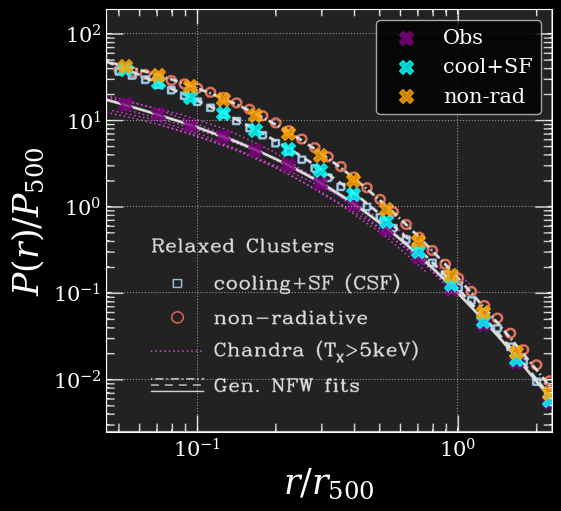

In [148]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, ax = Plots.Nagai2007().FigA1()

hmod = HaloModels.pyccl_model(Profiles.Nagai2007().info)
rs, z, logM500c = np.geomspace(1e-2, 1e1, 25), 3, np.log10(9e13)
x = rs*u.Mpc/hmod.rdel('500c')(z, logM500c)
P_del = lambda N07: (N07.Pressure(rs, z, logM500c)()/N07.P500(z, logM500c)())[:, 0, 0]
N07 = lambda **spefs: Profiles.Nagai2007(**spefs, H=hmod.H, rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))

ax.scatter(x, P_del(N07(Run='Obs', Sample='Rel')), s=100, marker='X', alpha=0.8, c='purple', label='Obs')
ax.scatter(x, P_del(N07(Run='CSF', Sample='Rel')), s=100, marker='X', alpha=0.8, c='cyan', label='cool+SF')
ax.scatter(x, P_del(N07(Run='NR', Sample='Rel')), s=100, marker='X', alpha=0.8, c='orange', label='non-rad')

ax.legend(); plt.show()

## Arnaud 2010

$p(x) = \frac{P(r)}{P_{500}}$
$\qquad$ (4) $\qquad$
$x=\frac{r}{R_{500}}$

$P_{500} = 1.65\times10^{-3} h(z)^{8/3} \bigg[ \frac{M_{500}}{3 \times 10^{14} \text{h}_{70}^{-1} M_\odot} \bigg]^{2/3} \text{h}_{70}^2 \text{keV cm}^{-3}$
$\qquad$ (5)

$\alpha_P = \frac{1}{\alpha_{\text{MY}_\text{X}}}-\frac{5}{3}=0.12$
$\qquad$ (7) $\qquad$
$\alpha_{\text{MY}_\text{X}}=0.561$

$p(x, M_{500}) = \mathbb{P}(x) \bigg[ \frac{M_{500}}{3 \times 10^{14} \text{h}_{70}^{-1} M_\odot} \bigg]^{\alpha_P=0.12}$
$\qquad$ (8) $\qquad$

$\alpha_P'(x)=0.10-(\alpha_P+0.10) \frac{(x/0.5)^3}{1+(x/0.5)^3}$
$\qquad$ (9) $\qquad$

$p(x, M_{500}) = \mathbb{P}(x) \bigg[ \frac{M_{500}}{3 \times 10^{14} \text{h}_{70}^{-1} M_\odot} \bigg]^{\alpha_P+\alpha_p'(x)}$
$\qquad$ (10) $\qquad$

$\mathbb{P}(x) = \frac{P_0}{(c_{500}x)^\gamma (1+(c_{500}x)^\alpha)^{(\beta-\gamma)/\alpha}}$
$\qquad$ (11) $\qquad$
$r_s=r_{500}/c_{500}$

$P(r) = P_{500} \bigg[ \frac{M_{500}}{3 \times 10^{14} \text{h}_{70}^{-1} M_\odot} \bigg]^{\alpha_P+\alpha_p'(x)} \mathbb{P}(x)$
$\qquad$ (13) $\qquad$
$x=\frac{r}{R_{500}}$


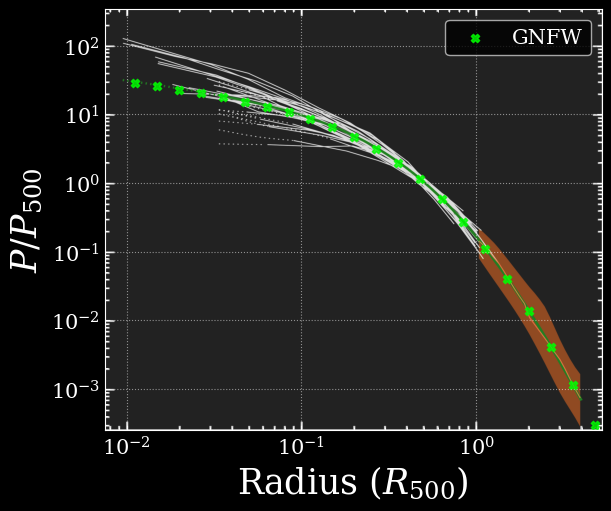

In [149]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, ax = Plots.Arnaud2010().Fig8()

hmod = HaloModels.pyccl_model(Profiles.Arnaud2010().info)
r, z, logM500c = np.geomspace(1e-2, 1e1, 25), 0, np.log10(2e14)

A10 = Profiles.Arnaud2010(H=hmod.H, rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))

x = r/hmod.rdel('500c')(z, logM500c)
P_del = (A10.Pressure(r, z, logM500c)()/A10.P500(z, logM500c)())[:, 0, 0]
ax.scatter(x, P_del, marker='X', alpha=0.8, c='lime', label='GNFW')

ax.legend()
plt.show()

## Battaglia 2011

$P_\Delta = GM_\Delta \Delta \rho_\text{cr}f_\text{b}/(2R_\Delta)
, \quad f_\text{b} = \Omega_b/\Omega_m
, \quad \bar{P}_\text{th} = \langle P_\text{th} / P_\Delta \rangle$

$\bar{P}_\text{fit} = \langle P_\text{th} / P_\Delta \rangle  = P_0 (x/x_c)^\gamma [1+(x/x_c)^\alpha]^{-\beta}
, \quad x=r/R_\Delta
\qquad (10)$

$\alpha=1.0
, \quad \gamma=-0.3$

$A = A_0 \Big(\frac{M_{200}}{10^{14} M_\odot}\Big)^{\alpha_m} (1+z)^{\alpha_z}
,\qquad \text{(11)}$

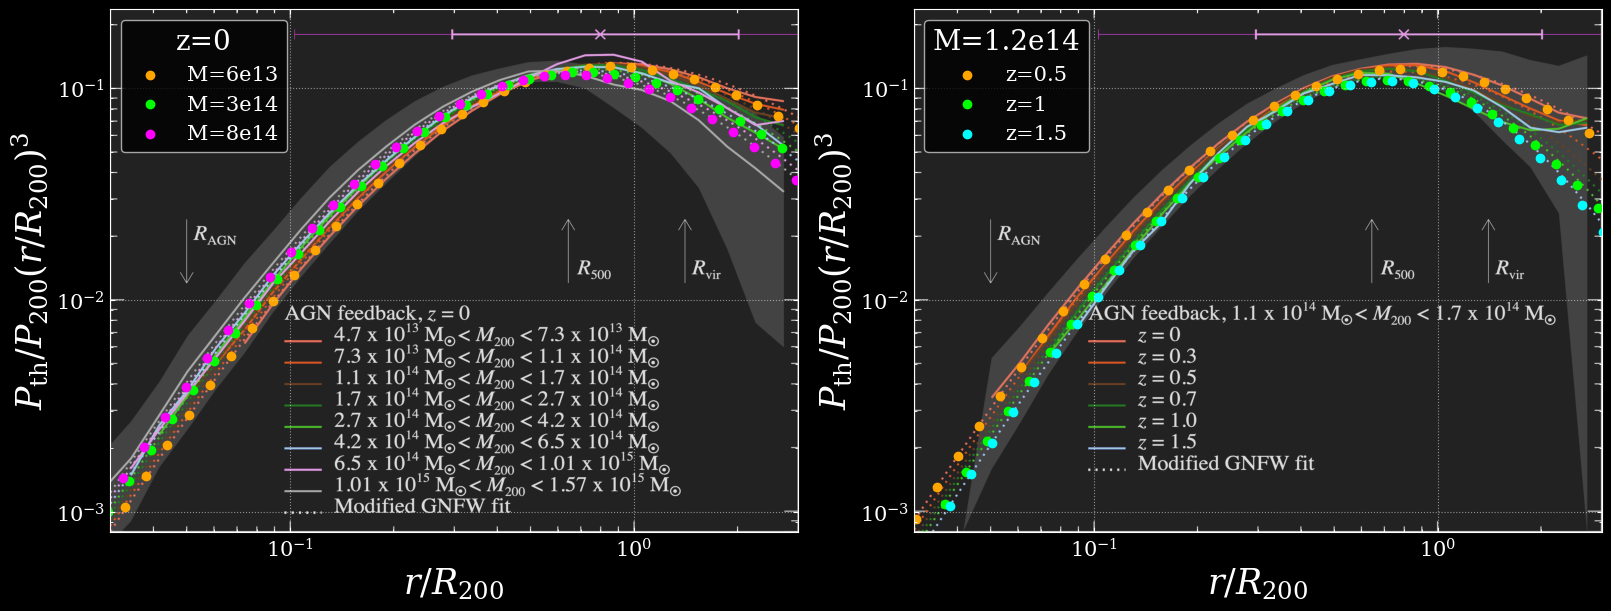

In [153]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Battaglia2011().Fig2()

hmod = HaloModels.pyccl_model(Profiles.Battaglia2011().info)
r = np.geomspace(1e-2, 1e1, 50)
z, logM200c = 0, np.log10(1.2e14)
x = lambda z, logM200c: r*u.Mpc/hmod.rdel('200c')(z, logM200c)

B11 = Profiles.Battaglia2011(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
pfunc = lambda z, logM200c: (B11.Pressure(r, z, logM200c)()/B11.P200c(z, logM200c)())[:, 0, 0]*x(z, logM200c)**3

axs[0].scatter(x(z, np.log10(6e13)), pfunc(z, np.log10(6e13)), c='orange', label='M=6e13')
axs[0].scatter(x(z, np.log10(3e14)), pfunc(z, np.log10(3e14)), c='lime', label='M=3e14')
axs[0].scatter(x(z, np.log10(8e14)), pfunc(z, np.log10(8e14)), c='magenta', label='M=8e14')

axs[1].scatter(x(0, logM200c), pfunc(0, logM200c), c='orange', label='z=0.5')
axs[1].scatter(x(1, logM200c), pfunc(1, logM200c), c='lime', label='z=1')
axs[1].scatter(x(1.5, logM200c), pfunc(1.5, logM200c), c='cyan', label='z=1.5')

axs[0].legend(title='z=0'); axs[1].legend(title='M=1.2e14')
plt.show()

## Battaglia 2016

$\bar{\rho}_\text{gas} = F_b \rho_\text{crit} \bar{\rho}_\text{fit}$

$\bar{\rho}_\text{fit} = \rho_0(x/x_c)^\gamma[1+(x/x_c)^\alpha]^{-\big(\frac{\beta\textcolor{lime}+\gamma}{\alpha}\big)}$
$,\qquad x=r/R_\Delta$
$,\qquad \text{(A1)}$

$x_c=0.5, \qquad \gamma=-0.2$

$A = A_0 \Big(\frac{M_\Delta}{10^{14} M_\odot}\Big)^{\alpha_m} (1+z)^{\alpha_z}$
$\qquad \text{(A2)} \qquad$

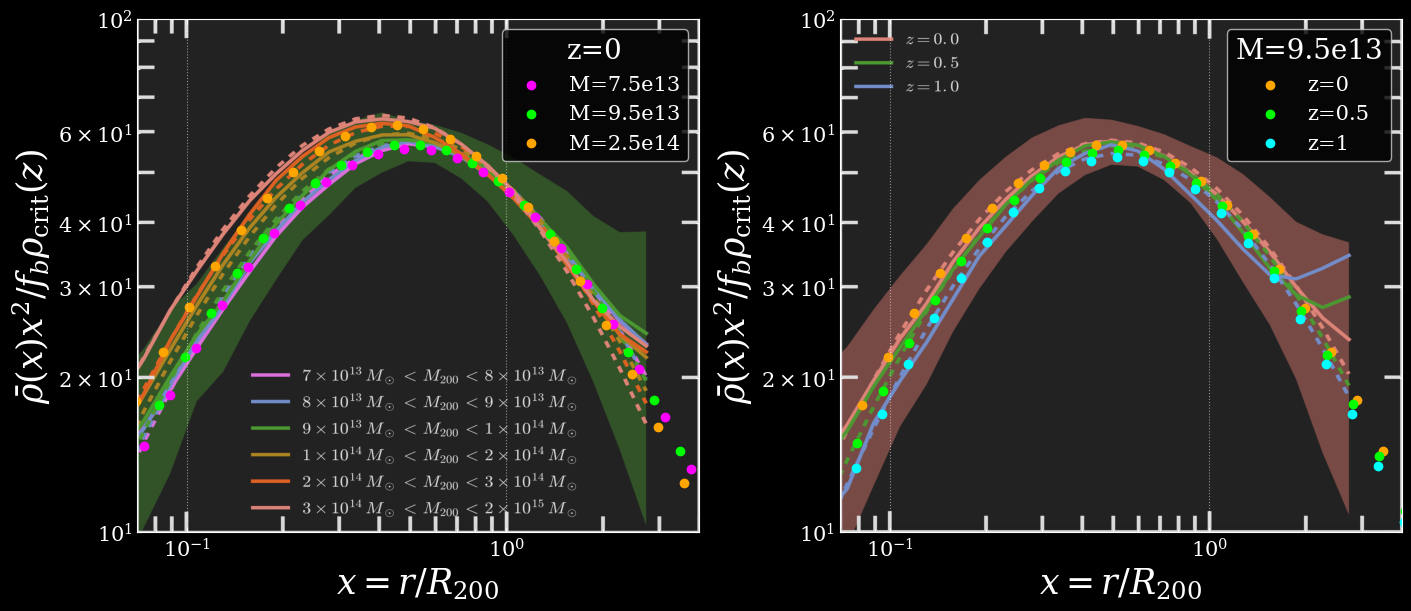

In [155]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Battaglia2016().Fig5()

hmod = HaloModels.pyccl_model(Profiles.Battaglia2016({'model':'AGN'}).info)

B16 = Profiles.Battaglia2016({'model':'AGN'}, rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))

rs = np.geomspace(1e-3, 1e1, 50)
z, logMh = 0, np.log10(9.5e13)
xs = lambda z0, logMh0: rs*u.Mpc/B16.r200c(z0, logMh0)
pfunc = lambda z0, logMh0: (B16.Density(rs, z0, logMh0)()/B16.pc(z0)())[:, 0, 0]*xs(z0, logMh0)**2

axs[0].scatter(xs(z, np.log10(7.5e13)), pfunc(z, np.log10(7.5e13)), c='magenta', label='M=7.5e13')
axs[0].scatter(xs(z, np.log10(9.5e13)), pfunc(z, np.log10(9.5e13)), c='lime', label='M=9.5e13')
axs[0].scatter(xs(z, np.log10(2.7e14)), pfunc(z, np.log10(2.7e14)), c='orange', label='M=2.5e14')

axs[1].scatter(xs(0, logMh), pfunc(0, logMh), c='orange', label='z=0')
axs[1].scatter(xs(0.5, logMh), pfunc(0.5, logMh), c='lime', label='z=0.5')
axs[1].scatter(xs(1, logMh), pfunc(1, logMh), c='cyan', label='z=1')

axs[0].legend(title='z=0'); axs[1].legend(title='M=9.5e13')
plt.show()

# All Plot

In [ ]:
importlib.reload(Profiles)
fig, axs = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')
fig.suptitle(f'$z$={z}, log$M_h$={logM200c}', fontsize=30)
axs[0].set(ylabel=r'$P_\text{th} \ [\text{dyne} \ \text{cm}^{-2}]$', xlabel=r'$r \ [\text{Mpc}]$', xlim=(1e-1, 1e1), ylim=(1e-16, 1e-11))
axs[1].set(ylabel=r'$P_\text{th} \ / \ P_\Delta \cdot x^2$', xlabel=r'$x=r/r_{200c}$', xlim=(1e-2, 1e1), ylim=(1e-4, 1e0))


# rs, z, logM200c = np.geomspace(1e-3, 1e2, 100), 0.55, 13.4
# def plot(model, name, color):
#     axs[0].loglog(rs, model.pres(rs, z, logM500c, units='cgs')()[:, 0, 0], c=color, label=name)
#     axs[1].loglog(xs, model.P_del(rs, z, logM500c)()[:, 0, 0]*xs**2, c=color, label=name)


hmod = HaloModels.pyccl_model(Profiles.Nagai2007().info)
xs = rs*u.Mpc/hmod.rdel('200c')(z, logM200c)
N07 = Profiles.Nagai2007(Run='Obs', Sample='Rel', r500c=hmod.rdel('500c'), H=hmod.H,rhoc=hmod.rhoc)
logM500c = HaloModels.pyccl_model(Profiles.Nagai2007().info, MassDef='200c').logM_conv(z, logM200c, '500c', c0=N07.p0['c500'])
axs[0].loglog(rs, N07.pres(rs, z, logM500c, units='cgs')()[:, 0, 0], c='indianred', label='Nagai 2007')
axs[1].loglog(xs, N07.P_del(rs, z, logM500c)()[:, 0, 0]*xs**2, c='indianred', label='Nagai 2007')

hmod = HaloModels.pyccl_model(Profiles.Arnaud2010().info)
A10 = Profiles.Arnaud2010(rhoc=hmod.rhoc, r500c=hmod.rdel('500c'), H=hmod.H)
logM500c = HaloModels.pyccl_model(Profiles.Arnaud2010().info, MassDef='200c').logM_conv(z, logM200c, '500c', c0=N07.p0['c500'])
axs[0].loglog(rs, A10.pres(rs, z, logM500c, units='cgs')()[:, 0, 0], c='springgreen', label='Arnaud 2010')
axs[1].loglog(xs, A10.P_del(rs, z, logM500c)()[:, 0, 0]*xs**2, c='springgreen', label='Arnaud 2010')

hmod = HaloModels.pyccl_model(Profiles.Battaglia2011().info)
B11 = Profiles.Battaglia2011(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
axs[0].loglog(rs, B11.pres(rs, z, logM200c, units='cgs')()[:, 0, 0], c='turquoise', label='Battaglia 2011')
axs[1].loglog(xs, B11.P_del(rs, z, logM200c)()[:, 0, 0]*xs**2, c='turquoise', label='Battaglia 2011')

axs[0].legend(); axs[1].legend()
plt.show()

# Unchecked

## Planck 2013

TypeError: Arnaud2010.PGNFW() missing 3 required positional arguments: 'beta', 'P0', and 'c500'

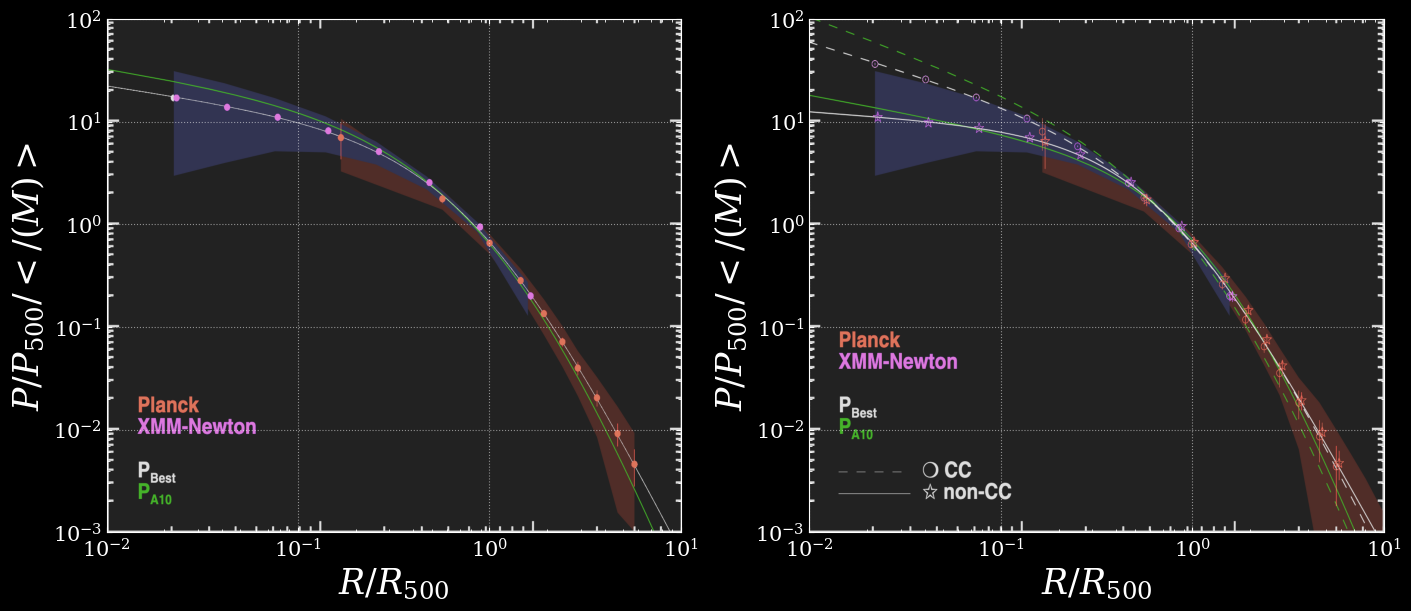

In [156]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Planck2013().Fig4()

r = np.geomspace(1e-3, 1e1, 50)
z, logM500c = 0.2, np.log10(2e13)
hmod = HaloModels.pyccl_model(Profiles.Planck2013().info)
x = r*u.Mpc/hmod.rdel('500c')(z, logM500c)

P_del = lambda P13: (P13.Pressure(r*0.7**2, z, logM500c)()/P13.P500(z, logM500c)())[:, 0, 0]

P13 = lambda **spefs: Profiles.Planck2013(**spefs, H=hmod.H, rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))
axs[0].scatter(x, P_del(P13(cluster='All',fixedp='1')), marker='o', alpha=0.5, c='w', label='P13 all')
axs[1].scatter(x, P_del(P13(cluster='cool')), marker='o', alpha=0.5, c='w', label='P13 cool')   
axs[1].scatter(x, P_del(P13(cluster='noncool')), marker='x', alpha=0.5, c='w', label='P13 noncool')                                                                            

A10 = lambda **spefs: Profiles.Arnaud2010(**spefs, H=hmod.H, rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))
axs[0].scatter(x, P_del(A10()), marker='o', alpha=0.5, c='g', label='A10')
axs[1].scatter(x, P_del(A10()), marker='o', alpha=0.5, c='g', label='A10')                                                     

axs[0].legend(); axs[1].legend()
plt.show()

AttributeError: 'Planck2013' object has no attribute 'P_del'

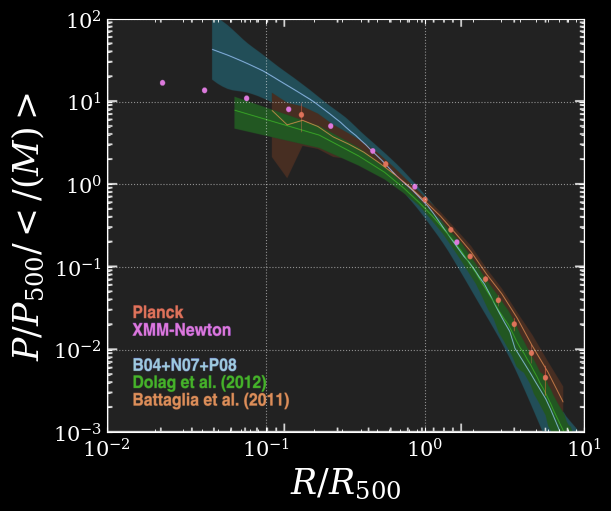

In [ ]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, ax = Plots.Planck2013().Fig6()

rs = np.geomspace(1e-3, 1e1, 50)
z, logMh = 1, np.log10(5e14)

hmod = HaloModels.pyccl_model(Profiles.Planck2013().info)
P13 = Profiles.Planck2013(cluster='All', fixedp='3',rhoc=hmod.rhoc, r500c=hmod.rdel('500c'))
ax.scatter(rs/hmod.rdel('500c')(z, logMh), P13.P_del(rs, z, logMh)()[:, 0, 0], marker='x', alpha=0.8, c='red', label='Planck')          

# logM200c = HaloModels.pyccl_model(Profiles.Battaglia2011().info, MassDef='500c', Concentration='Constant').logM_conv(z, logMh, '200c', c0=1)
# hmod200c = HaloModels.pyccl_model(Profiles.Battaglia2011().info)
# Battaglia11 = Profiles.Battaglia2011(rhoc=hmod200c.rhoc, r200c=hmod200c.rdel('200c'))
# ax.scatter(rs/hmod.rdel('500c')(z, logMh), P13.pres(rs, z, logMh)()[:, 0, 0]/, marker='X', alpha=0.8, c='lime', label='B11')

ax.legend()
plt.show()

## Moser 2021

$\frac{p(x)}{\rho_\text{cr}} = f_b \rho_0 (x/x_{c, k})^{\gamma_k} [1+(x/x_{c, k})^{\alpha_k}]^{-\frac{\beta_k-\gamma_k}{\alpha_k}}$
$\qquad \text{(5)} \qquad$
$x=r/r_{200c}, f_b=\Omega_b/\Omega_m$

$\frac{P(x)}{P_{200c}} = P_0 (x/x_{c, t})^{\gamma_t} [1+(x/x_{c, t})^{\alpha_t}]^{-\beta_t}$
$\qquad \text{(6)} \qquad$
$P_{200c} = \frac{200GM_{200c}\rho_\text{cr}(z)f_b}{2r_{200c}}$

$\alpha_t=1.0, \gamma_T=-0.3, x_{c, k}=0.5, \gamma_k=-0.2$
$\qquad \text{(Table 1)} \qquad$

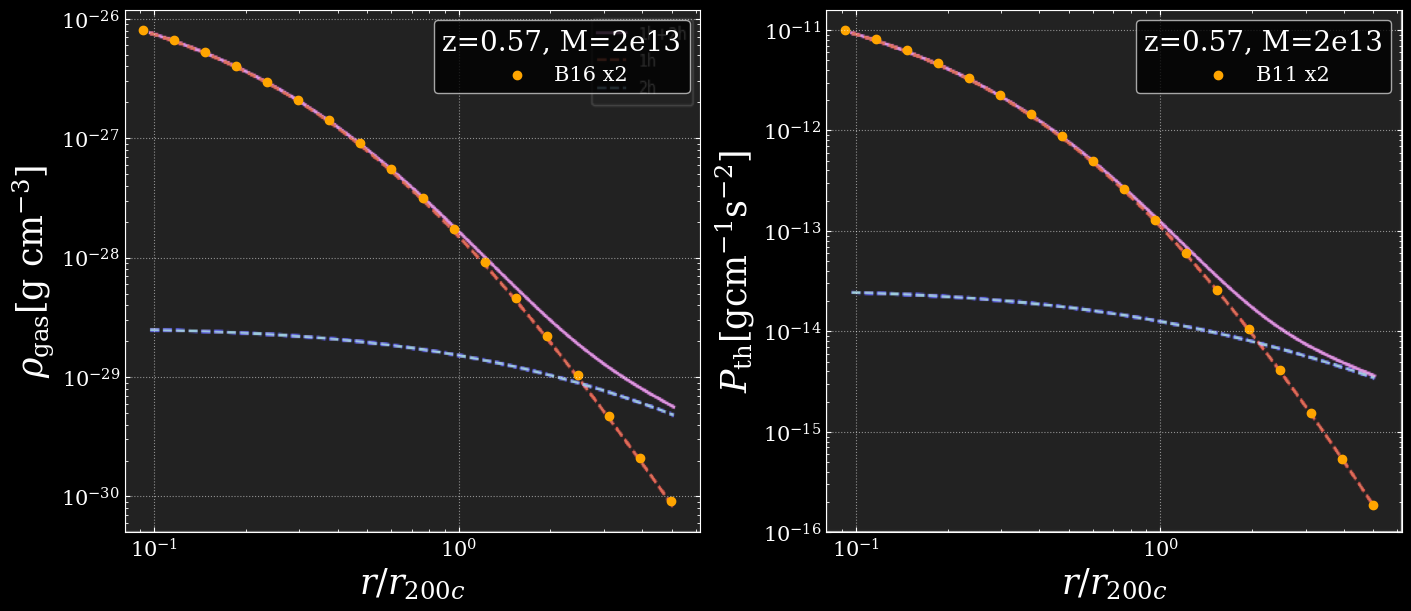

In [157]:
fig, axs = Plots.Moser2021().Fig2()

import HaloModels, Profiles
import Models.HaloModels as HaloModels
importlib.reload(HaloModels)
importlib.reload(Profiles)

rs, z, logM = np.geomspace(1e-3, 1e2, 50), 0.57, np.log10(2e13)

hmod = HaloModels.pyccl_model(Studies.Amodeo2021().info)
xs = rs*u.Mpc/hmod.rdel('200c')(z, logM)
B11 = Profiles.Battaglia2011(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
B16 = Profiles.Battaglia2016(model='AGN', rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
ptypo = {'beta_A0': B16.p0['beta_A0']-2*B16.p0['gamma']}
axs[0].scatter(xs, B16.Density(rs, z, logM, units='cgs')(ptypo)[:, 0, 0]*2.1, c='orange', label='B16 x2')
axs[1].scatter(xs, B11.Pressure(rs, z, logM, units='cgs')()[:, 0, 0]*2, c='orange', label='B11 x2')

# hmod2 = HaloModels.pyccl_model(MassDef='fof', MassFunc='sheth99', HaloBias='sheth01', PowSpec='LINEAR')
# dndlogm2 = lambda z, logm: hmod2.dndlogm(z, hmod.logM_conv(z, logm, 'fof')-np.log10(hmod2.params['h']))*hmod2.params['h']**4
# bh2 = lambda z, logm: hmod2.bh(z, logm-np.log10(hmod2.params['h']))
# Plin2 = lambda k, z: hmod2.Plin(k*hmod2.params['h'], z)/hmod2.params['h']**3

# hmod2 = HaloModels.mopc_model()

# Moser2021 = Profiles.Moser2021(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), **Studies.Amodeo2021().info, dndlogm=hmod2.dndlogm, bh=hmod2.bh, Plin=hmod2.Plin)
# axs[0].scatter(xs, Moser2021.dens2h(rs, z, logM, units='cgs')()[:, 0, 0]*2, c='cyan', label='M21 2h x2')
# axs[1].scatter(xs, Moser2021.pres2h(rs, z, logM, units='cgs')()[:, 0, 0]*2*2, c='cyan', label='M21 2h x4')

# axs[0].scatter(xs, Moser2021.dens1h(rs, z, logM, units='cgs')({'logrho0':np.log10(4e3), 'alpha_k':0.88, 'beta_k':3.83})[:, 0, 0], c='magenta', label='1h')
# axs[1].scatter(xs, Moser2021.pres1h(rs, z, logM, units='cgs')()[:, 0, 0], c='magenta', label='1h')

axs[0].legend(title='z=0.57, M=2e13'); axs[1].legend(title='z=0.57, M=2e13')
plt.show()

In [4]:
b_cen = np.array(
    [
        [
            11.31932504,
            11.43785913,
            11.57526319,
            11.74539764,
            11.97016907,
            12.27689266,
            12.67884686,
            13.16053855,
            13.69871423,
        ]
    ]
).T
p = np.array(
    [
        2.94467222e-06,
        2.94467222e-06,
        2.94467222e-06,
        1.47233611e-05,
        3.38637305e-05,
        4.13431979e-03,
        1.31666601e-01,
        3.36540698e-01,
        8.13760167e-02,
    ]
)

b_cen = np.array([[12.27689266, 12.67884686, 13.16053855, 13.69871423]]).T
p = np.array([4.13431979e-03, 1.31666601e-01, 3.36540698e-01, 8.13760167e-02])

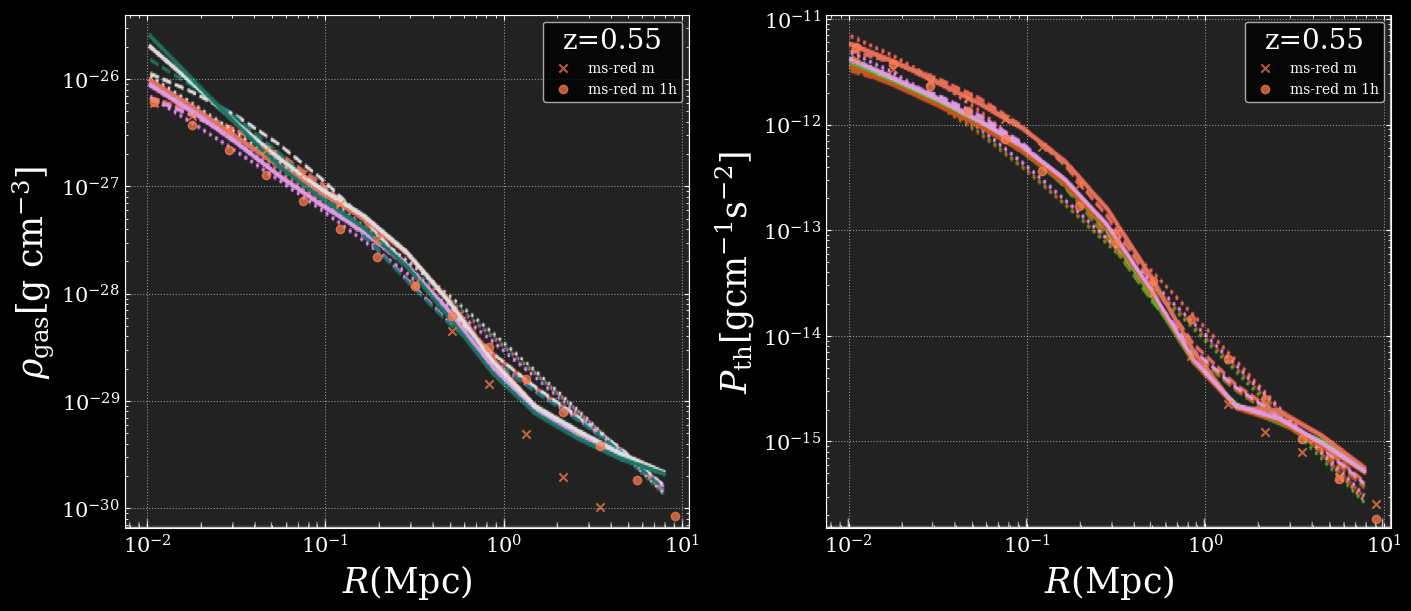

In [54]:
fig, axs = Plots.Moser2021().Fig4row1()

import HaloModels, Profiles
importlib.reload(Profiles)

hmod = HaloModels.colossus_model(Studies.Amodeo2021().info, PlinMod='eisenstein98')
rs, z = np.geomspace(1e-3, 1e2, 25), 0.55
MoserModel = lambda inps: Profiles.Moser2021(inps,rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin, **Studies.Amodeo2021().info)

Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, np.average(Moser2021.dens(rs, z, b_cen.T[0], units='cgs')()[:, 0, :], weights=p, axis=-1), alpha=0.7, marker='x', c='coral', label=f'ms-red m')
axs[1].scatter(rs, np.average(Moser2021.pres(rs, z, b_cen.T[0], units='cgs')()[:, 0, :], weights=p, axis=-1), alpha=0.7, marker='x', c='coral', label=f'ms-red m')

Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, np.average(Moser2021.dens(rs, z, b_cen.T[0], units='cgs')()[:, 0, :], weights=p, axis=-1), alpha=0.7, marker='o', c='coral', label=f'ms-red m 1h')
axs[1].scatter(rs, np.average(Moser2021.pres(rs, z, b_cen.T[0], units='cgs')()[:, 0, :], weights=p, axis=-1), alpha=0.7, marker='o', c='coral', label=f'ms-red m 1h')

# Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
# axs[0].scatter(rs, Moser2021.dens(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='w', label=f'ms-tot m, logM={logM_ms_t_m}')

# Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
# axs[0].scatter(rs, Moser2021.dens(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='w', label=f'ms-tot m 1h, logM={logM_ms_t_m}')

# Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
# axs[0].scatter(rs, Moser2021.dens(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='magenta', label=f'mh-red m, logM={logM_mh_r_m}')
# axs[1].scatter(rs, Moser2021.pres(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='magenta', label=f'mh-red m, logM={logM_mh_r_m}')

# Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
# axs[0].scatter(rs, Moser2021.dens(rs, z, 12.9, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='magenta', label='mh-red m 1h, logM=12.9')
# axs[1].scatter(rs, Moser2021.pres(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='magenta', label=f'mh-red m 1h, logM={logM_mh_r_m}')

# Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
# axs[0].scatter(rs, Moser2021.dens(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='teal', label=f'mh-tot m, logM={logM_mh_t_m}')

# Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
# axs[0].scatter(rs, Moser2021.dens(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='teal', label=f'mh-tot m h, logM={logM_mh_t_m}')

# Moser2021 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
# axs[1].scatter(rs, Moser2021.pres(rs, z, logM_ms_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='lime', label=f'ms-red um, logM={logM_ms_r_um}')

# Moser2021 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
# axs[1].scatter(rs, Moser2021.pres(rs, z, logM_ms_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='lime', label=f'ms-red um 1h, logM={logM_ms_r_um}')

# Moser2021 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
# axs[1].scatter(rs, Moser2021.pres(rs, z, logM_mh_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='orange', label=f'mh-red um, logM={logM_mh_r_um}')

# Moser2021 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
# axs[1].scatter(rs, Moser2021.pres(rs, z, logM_mh_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='orange', label=f'mh-red um 1h, logM={logM_mh_r_um}')

axs[0].legend(title='z=0.55', fontsize=10); axs[1].legend(title='z=0.55', fontsize=10)
plt.show()

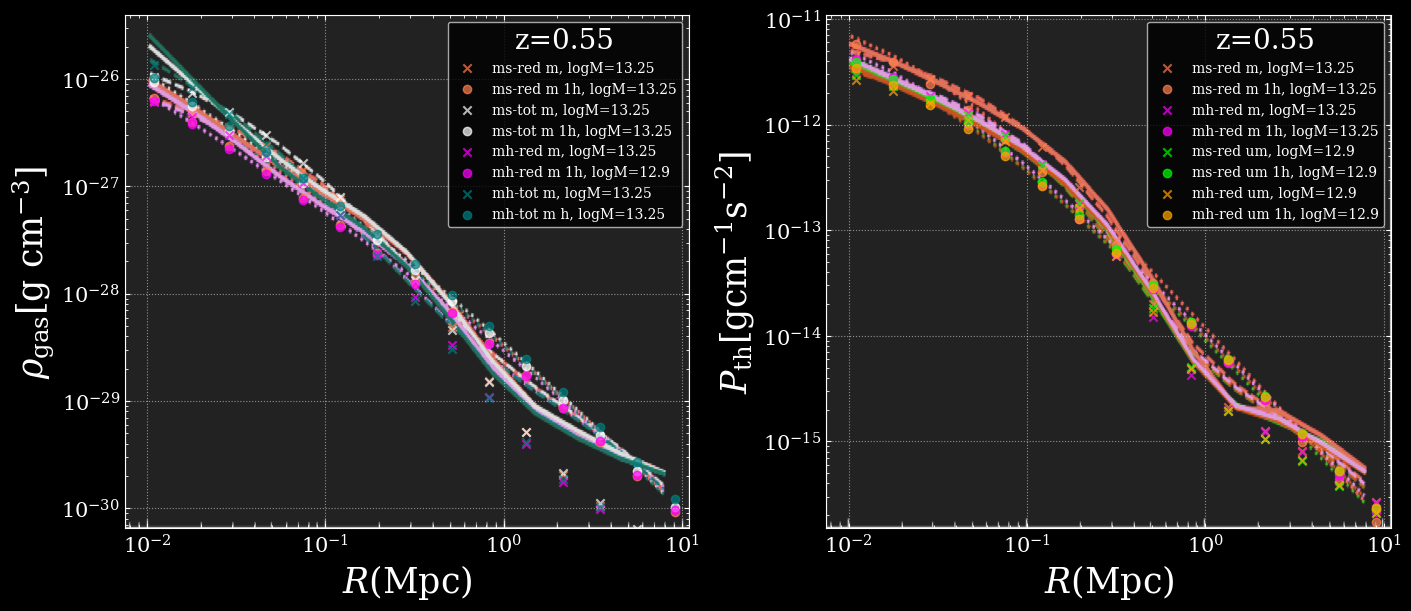

In [13]:
fig, axs = Plots.Moser2021().Fig4row1()

import HaloModels, Profiles
importlib.reload(Profiles)

hmod = HaloModels.colossus_model(Studies.Amodeo2021().info, PlinMod='eisenstein98')
rs, z = np.geomspace(1e-3, 1e2, 25), 0.55
MoserModel = lambda inps: Profiles.Moser2021(inps,rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin, **Studies.Amodeo2021().info)

logM_ms_r_m = 13.25
logM_ms_t_m = 13.25
logM_mh_r_m = 13.25
logM_mh_t_m = 13.25

logM_ms_r_um = 12.9
logM_ms_t_um = 12.9
logM_mh_r_um = 12.9
logM_mh_t_um = 12.9

Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, logM_ms_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='coral', label=f'ms-red m, logM={logM_ms_r_m}')
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_ms_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='coral', label=f'ms-red m, logM={logM_ms_r_m}')

Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, logM_ms_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='coral', label=f'ms-red m 1h, logM={logM_ms_r_m}')
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_ms_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='coral', label=f'ms-red m 1h, logM={logM_ms_r_m}')

Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='w', label=f'ms-tot m, logM={logM_ms_t_m}')

Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='w', label=f'ms-tot m 1h, logM={logM_ms_t_m}')

Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='magenta', label=f'mh-red m, logM={logM_mh_r_m}')
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='magenta', label=f'mh-red m, logM={logM_mh_r_m}')

Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, 12.9, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='magenta', label='mh-red m 1h, logM=12.9')
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_mh_r_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='magenta', label=f'mh-red m 1h, logM={logM_mh_r_m}')

Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='teal', label=f'mh-tot m, logM={logM_mh_t_m}')

Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='teal', label=f'mh-tot m h, logM={logM_mh_t_m}')

Moser2021 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_ms_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='lime', label=f'ms-red um, logM={logM_ms_r_um}')

Moser2021 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_ms_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='lime', label=f'ms-red um 1h, logM={logM_ms_r_um}')

Moser2021 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'red', 'model':'GNFW', 'fit':'3D'})
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_mh_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='x', c='orange', label=f'mh-red um, logM={logM_mh_r_um}')

Moser2021 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'red', 'model':'GNFW1h', 'fit':'3D'})
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_mh_r_um, units='cgs')()[:, 0, 0], alpha=0.7, marker='o', c='orange', label=f'mh-red um 1h, logM={logM_mh_r_um}')

axs[0].legend(title='z=0.55', fontsize=10); axs[1].legend(title='z=0.55', fontsize=10)
plt.show()

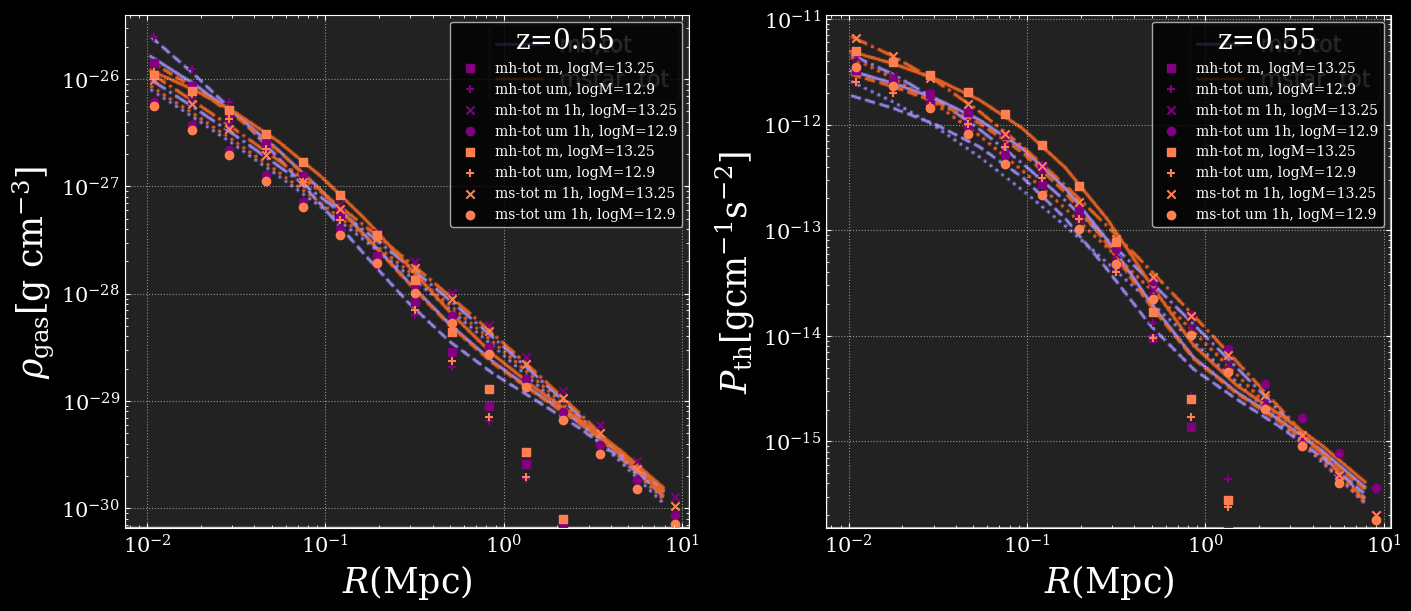

In [106]:
fig, axs = Plots.Moser2021().Fig6col1()

import HaloModels, Profiles
importlib.reload(Profiles)

hmod = HaloModels.colossus_model(Studies.Amodeo2021().info, PlinMod='eisenstein98')
rs, z = np.geomspace(1e-3, 1e2, 25), 0.55
MoserModel = lambda inps: Profiles.Moser2021(inps,rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin, **Studies.Amodeo2021().info)

Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens1h(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], marker='s', c='purple', label=f'mh-tot m, logM={logM_mh_t_m}')
axs[1].scatter(rs, Moser2021.pres1h(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], marker='s', c='purple', label=f'mh-tot m, logM={logM_mh_t_m}')

Moser2021 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens1h(rs, z, logM_mh_t_um, units='cgs')()[:, 0, 0], marker='+',c='purple', label=f'mh-tot um, logM={logM_mh_t_um}')
axs[1].scatter(rs, Moser2021.pres1h(rs, z, logM_mh_t_um, units='cgs')()[:, 0, 0], marker='+', c='purple', label=f'mh-tot um, logM={logM_mh_t_um}')

Moser2021 = MoserModel({'match':'matched', 'select':'halo', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens1h(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], marker='x', c='purple', label=f'mh-tot m 1h, logM={logM_mh_t_m}')
axs[1].scatter(rs, Moser2021.pres1h(rs, z, logM_mh_t_m, units='cgs')()[:, 0, 0], marker='x', c='purple', label=f'mh-tot m 1h, logM={logM_mh_t_m}')

Moser2021 = MoserModel({'match':'unmatched', 'select':'halo', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens1h(rs, z, logM_mh_t_um, units='cgs')()[:, 0, 0], c='purple', label=f'mh-tot um 1h, logM={logM_mh_t_um}')
axs[1].scatter(rs, Moser2021.pres1h(rs, z, logM_mh_t_um, units='cgs')()[:, 0, 0], c='purple', label=f'mh-tot um 1h, logM={logM_mh_t_um}')

Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens1h(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], marker='s', c='coral', label=f'mh-tot m, logM={logM_ms_t_m}')
axs[1].scatter(rs, Moser2021.pres1h(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], marker='s', c='coral', label=f'mh-tot m, logM={logM_ms_t_m}')

Moser2021 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'tot', 'model':'GNFW', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens1h(rs, z, logM_ms_t_um, units='cgs')()[:, 0, 0], marker='+',c='coral', label=f'mh-tot um, logM={logM_ms_t_um}')
axs[1].scatter(rs, Moser2021.pres1h(rs, z, logM_ms_t_um, units='cgs')()[:, 0, 0], marker='+', c='coral', label=f'mh-tot um, logM={logM_ms_t_um}')

Moser2021 = MoserModel({'match':'matched', 'select':'star', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens1h(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], marker='x', c='coral', label=f'ms-tot m 1h, logM={logM_ms_t_m}')
axs[1].scatter(rs, Moser2021.pres1h(rs, z, logM_ms_t_m, units='cgs')()[:, 0, 0], marker='x', c='coral', label=f'ms-tot m 1h, logM={logM_ms_t_m}')

Moser2021 = MoserModel({'match':'unmatched', 'select':'star', 'samp':'tot', 'model':'GNFW1h', 'fit':'3D'})
axs[0].scatter(rs, Moser2021.dens(rs, z, logM_ms_t_um, units='cgs')()[:, 0, 0], c='coral', label=f'ms-tot um 1h, logM={logM_ms_t_um}')
axs[1].scatter(rs, Moser2021.pres(rs, z, logM_ms_t_um, units='cgs')()[:, 0, 0], c='coral', label=f'ms-tot um 1h, logM={logM_ms_t_um}')


axs[0].legend(title='z=0.55', fontsize=10); axs[1].legend(title='z=0.55', fontsize=10)
plt.show()

## Amodeo 2021

AttributeError: 'Battaglia2016' object has no attribute 'p_del'

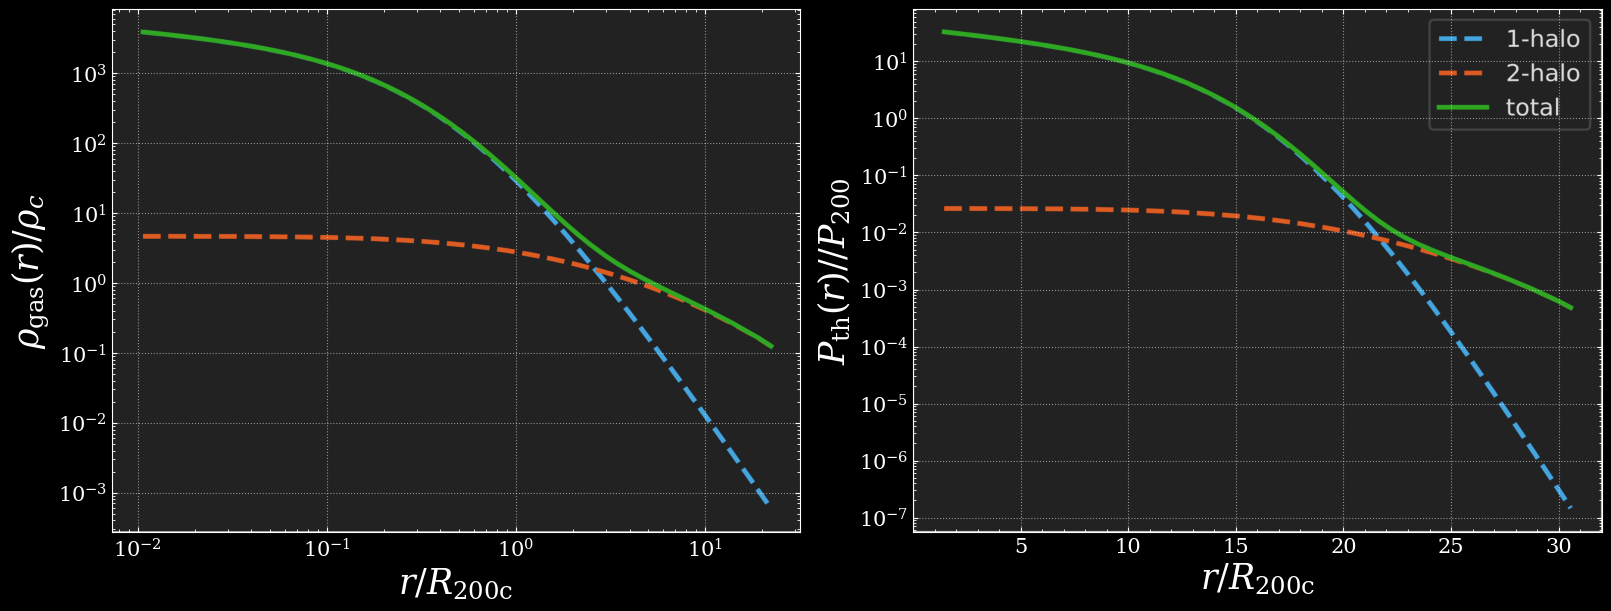

In [112]:
fig, axs = Plots.Amodeo2021().Fig7()

import HaloModels, Profiles
importlib.reload(Profiles)

rs, z, logM = np.geomspace(1e-3, 1e2, 50), Profiles.Amodeo2021().z_med, np.round(Profiles.Amodeo2021().logMhMean, 1)

hmod = HaloModels.colossus_model(Profiles.Amodeo2021().info)
xs = rs*u.Mpc/hmod.rdel('200c')(z, logM)
B11 = Profiles.Battaglia2011(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
B16 = Profiles.Battaglia2016({'model':'AGN'}, rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
axs[0].scatter(xs, B16.p_del(rs, z, logM, fixtypo=False)()[:, 0, 0], c='cyan', label='B16 1h')
axs[1].scatter(xs, B11.P_del(rs, z, logM)()[:, 0, 0], c='cyan', label='B11 1h')

hmod = HaloModels.pyccl_model(Profiles.Amodeo2021().info,PowSpec='LINEAR', Concentration='constant')
dndlogm2 = lambda z, logm: hmod.dndlogm(z, hmod.logM_conv(z, logm, 'fof')-np.log10(hmod.params['h']))*hmod.params['h']**4
bh2 = lambda z, logm: hmod.bh(z, logm-np.log10(hmod.params['h']))
Plin2 = lambda k, z: hmod.Plin(k*hmod.params['h'], z)/hmod.params['h']**3
xs = rs*u.Mpc/hmod.rdel('200c')(z, logM)

M21 = Profiles.Moser2021({'model':'GNFW'},rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=dndlogm2, bh=bh2, Plin=Plin2)

axs[0].scatter(xs, M21.p2h_del(rs, z, logM)()[:, 0, 0], c='magenta', label='M21 2h')
axs[1].scatter(xs, M21.P2h_del(rs, z, logM)()[:, 0, 0]/0.7**3, c='magenta', label='M21 2h')

axs[0].legend(); axs[1].legend()
plt.show()

In [82]:
b_cen = np.array([12.27689266, 12.67884686, 13.16053855, 13.69871423])
p = np.array([4.13431979e-03, 1.31666601e-01, 3.36540698e-01, 8.13760167e-02])

rho = A21.dens1h(rs, np.array([z]), b_cen, units='cgs')()
rho_av = np.average(rho, weights=p, axis=-1)[:, 0]

pth = A21.pres1h(rs, np.array([z]), b_cen, units='cgs')()
pth_av = np.average(pth, weights=p, axis=-1)[:, 0]

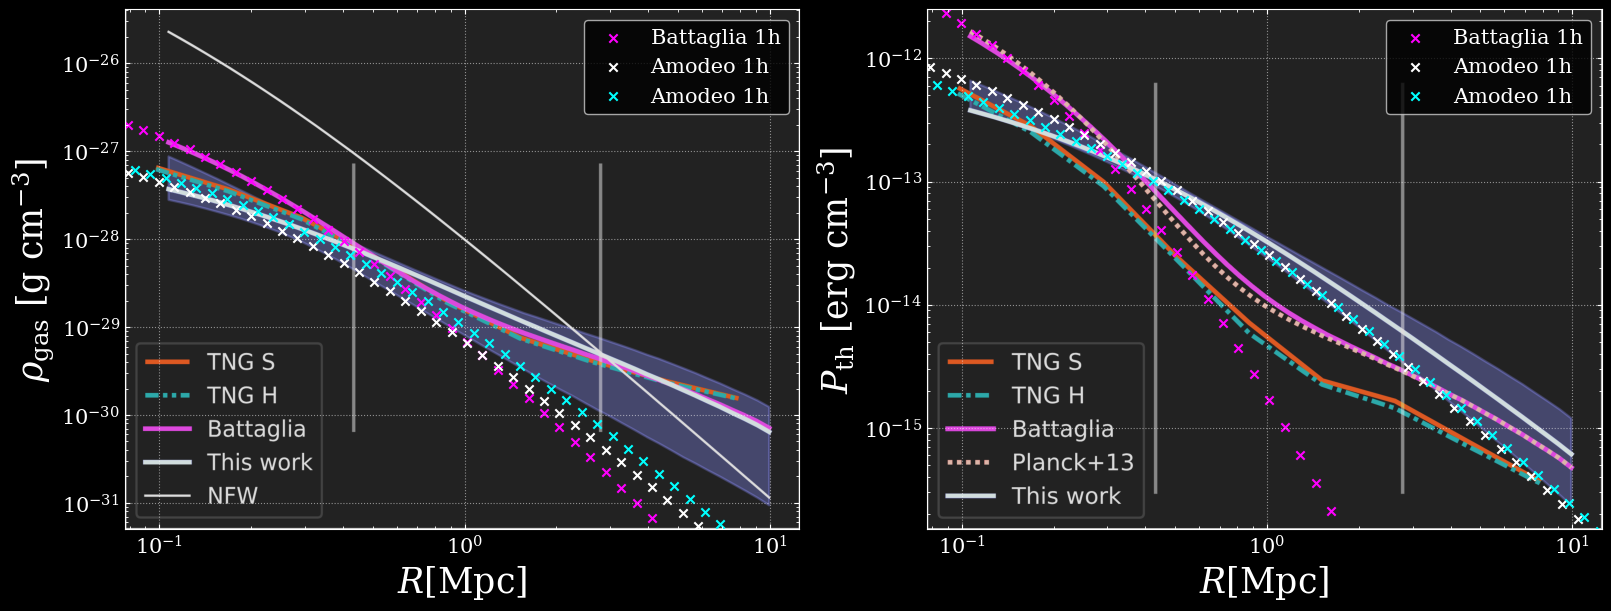

In [85]:
importlib.reload(Plots)
fig, axs = Plots.Amodeo2021().Fig6_row1()

import HaloModels, Profiles
importlib.reload(Profiles)

xsoff = 0.67
ysoff = 1

rs, z, logM = np.geomspace(1e-3, 1e2, 100), Profiles.Amodeo2021().z_med, np.round(Profiles.Amodeo2021().logMhMean, 2)

hmod = HaloModels.colossus_model(Profiles.Amodeo2021().info)
B11 = Profiles.Battaglia2011(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
B16 = Profiles.Battaglia2016({'model':'AGN'}, rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
axs[0].scatter(rs*xsoff, B16.dens(rs, z, logM, units='cgs', fixtypo=True)()[:, 0, 0]*ysoff, marker='x', c='magenta', label='Battaglia 1h')
axs[1].scatter(rs*xsoff, B11.pres(rs, z, logM, units='cgs')()[:, 0, 0]*ysoff, marker='x', c='magenta', label='Battaglia 1h')

xsoff = 0.67
ysoff = 1

hmod = HaloModels.colossus_model(Profiles.Amodeo2021().info,PlinMod='eisenstein98')
A21 = Profiles.Amodeo2021({'model':'GNFW'},rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin)
axs[0].scatter(rs*xsoff, A21.dens1h(rs, z, logM, units='cgs')()[:, 0, 0]*ysoff, marker='x', c='w', label='Amodeo 1h')
axs[1].scatter(rs*xsoff, A21.pres1h(rs, z, logM, units='cgs')()[:, 0, 0]*ysoff, marker='x', c='w', label='Amodeo 1h')

axs[0].scatter(rs, rho_av, marker='x', c='cyan', label='Amodeo 1h')
axs[1].scatter(rs, pth_av, marker='x', c='cyan', label='Amodeo 1h')


# axs[0].scatter(rs*0.7, Amodeo21.rho1h(rs, z, logM, units='cgs')()[:, 0, 0]+Amodeo21.rho2h(rs, z, logM)()[:, 0, 0]/0.7**7, c='w', label='Amodeo')
# axs[1].scatter(rs*0.7, Amodeo21.Pth1h(rs, z, logM, units='cgs')()[:, 0, 0]+Amodeo21.Pth2h(rs, z, logM)()[:, 0, 0]/0.7**7, c='w', label='Amodeo')

axs[0].legend(); axs[1].legend()
plt.show()

## Vikram 2017

AttributeError: 'Battaglia2011' object has no attribute 'P_del'

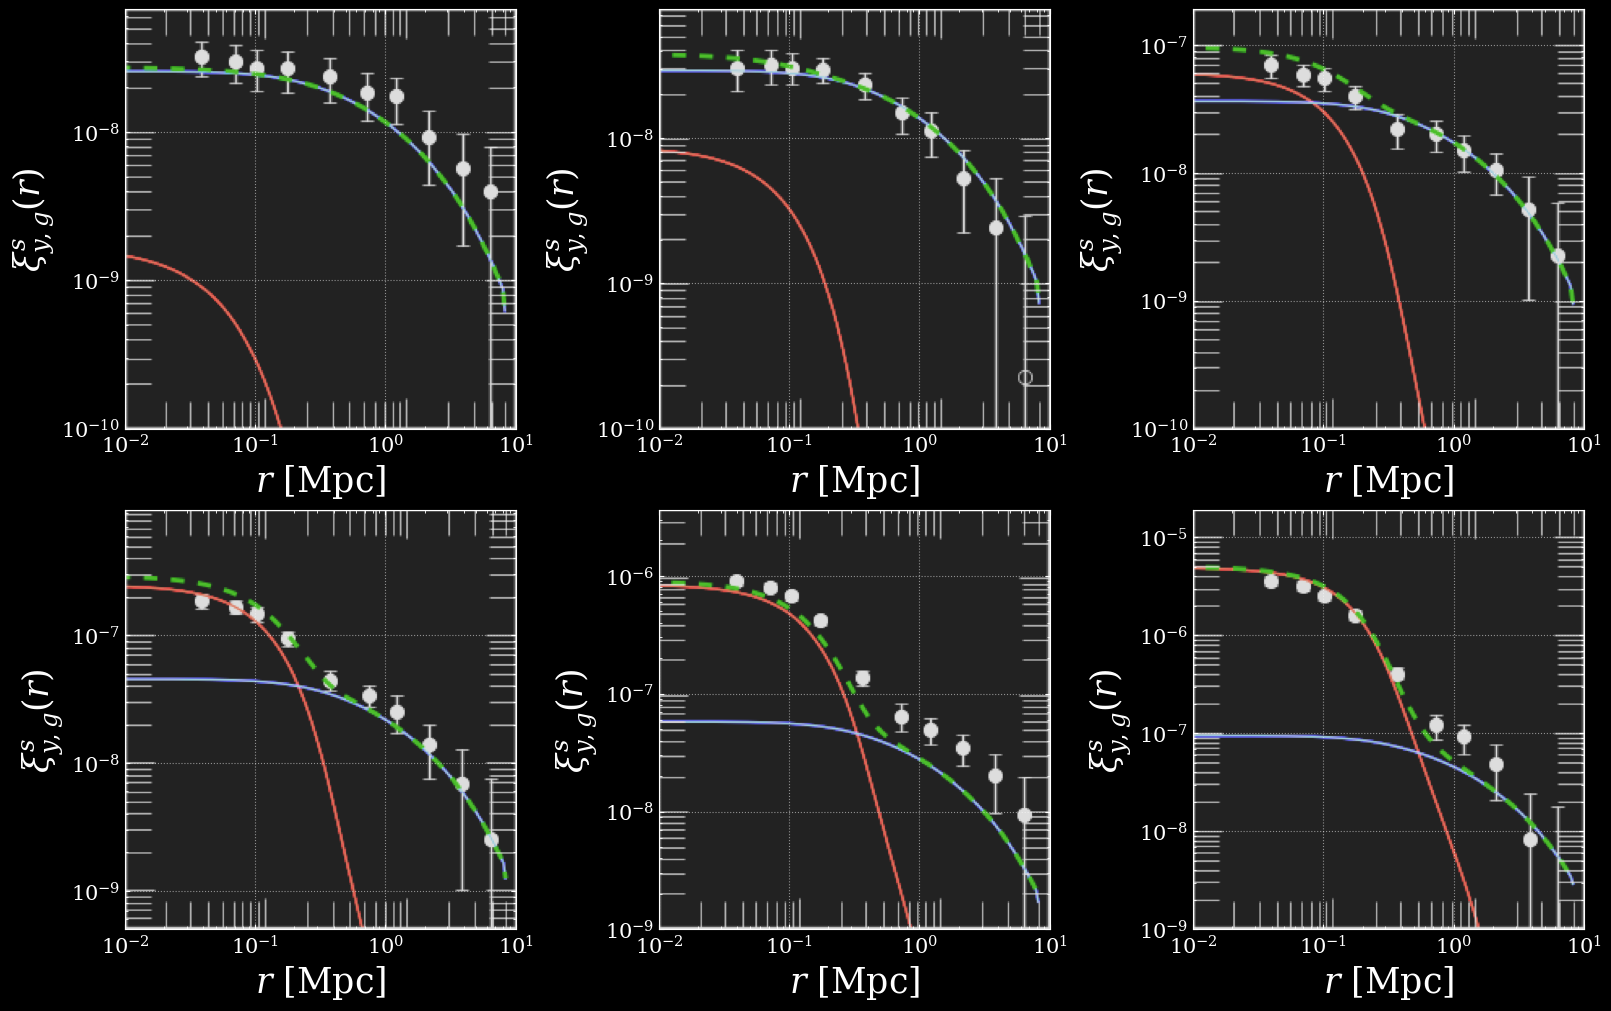

In [83]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Vikram2017().Fig3()

# import Studies, Profiles
# import Models.Studies as Studies
# importlib.reload(Studies); importlib.reload(Profiles)

hmod = HaloModels.pyccl_model(Profiles.Vikram2017().info)
rs = np.geomspace(1e-2, 1e1, 50)
z, logMh = 0, np.log10(1.2e14)

Vikram2017 = Profiles.Vikram2017(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))

axs[1].scatter(rs, Vikram2017.P1h(rs, z, logMh, units='cgs')(), c='orange', label='z=0.5')


for ax in axs.flatten(): ax.legend()
plt.show()

## Kou 2023

## Chen 2024

# All

In [ ]:
import Studies, HaloModels, Profiles
importlib.reload(Studies); importlib.reload(HaloModels); importlib.reload(Profiles)
import Models.Studies as Studies
importlib.reload(Studies)
import Models.HaloModels as HaloModels
importlib.reload(HaloModels)

rs, z, logM200c = np.geomspace(1e-3, 1e2, 100), 0.55, 13.4

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')
fig.suptitle(f'$z$={z}, log$M_h$={logM200c}', fontsize=30)
axs[0].set(ylabel=r'$P_\text{th} \ [\text{dyne} \ \text{cm}^{-2}]$', xlabel=r'$r \ [\text{Mpc}]$', xlim=(1e-1, 1e1), ylim=(1e-16, 1e-11))
axs[1].set(ylabel=r'$P_\text{th} \ / \ P_\Delta \cdot x^2$', xlabel=r'$x=r/r_{200c}$', xlim=(1e-2, 1e1), ylim=(1e-4, 1e0))


hmod = HaloModels.pyccl_model(Profiles.Nagai2007().info)
xs = rs*u.Mpc/hmod.rdel('200c')(z, logM200c)
N07 = Profiles.Nagai2007(Run='Obs', Sample='Rel', r500c=hmod.rdel('500c'), H=hmod.H,rhoc=hmod.rhoc)
logM500c = HaloModels.pyccl_model(Profiles.Nagai2007().info, MassDef='200c').logM_conv(z, logM200c, '500c', c0=N07.p0['c500'])
axs[0].loglog(rs, N07.pres(rs, z, logM500c, units='cgs')()[:, 0, 0], c='indianred', label='Nagai 2007')
axs[1].loglog(xs, N07.P_del(rs, z, logM500c)()[:, 0, 0]*xs**2, c='indianred', label='Nagai 2007')

hmod = HaloModels.pyccl_model(Profiles.Arnaud2010().info)
A10 = Profiles.Arnaud2010(rhoc=hmod.rhoc, r500c=hmod.rdel('500c'), H=hmod.H)
logM500c = HaloModels.pyccl_model(Profiles.Arnaud2010().info, MassDef='200c').logM_conv(z, logM200c, '500c', c0=N07.p0['c500'])
axs[0].loglog(rs, A10.pres(rs, z, logM500c, units='cgs')()[:, 0, 0], c='springgreen', label='Arnaud 2010')
axs[1].loglog(xs, A10.P_del(rs, z, logM500c)()[:, 0, 0]*xs**2, c='springgreen', label='Arnaud 2010')

hmod = HaloModels.pyccl_model(Profiles.Battaglia2011().info)
B11 = Profiles.Battaglia2011(rhoc=hmod.rhoc, r200c=hmod.rdel('200c'))
axs[0].loglog(rs, B11.pres(rs, z, logM200c, units='cgs')()[:, 0, 0], c='turquoise', label='Battaglia 2011')
axs[1].loglog(xs, B11.P_del(rs, z, logM200c)()[:, 0, 0]*xs**2, c='turquoise', label='Battaglia 2011')

# hmod = HaloModels.pyccl_model(Studies.Amodeo2021.info, MassDef='200c', MassFunc='Tinker08', HaloBias='Tinker10', Concentration='Diemer15', PowSpec='HALOFIT')
hmod = HaloModels.pyccl_model(Profiles.Moser2021().info)
M21 = Profiles.Moser2021(model='GNFW', match='matched', select='star',samp='tot', fit='3D',rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), )
# axs[0].loglog(rs, M21.pres(rs, z, logM200c, units='cgs')()[:, 0, 0], ls='--', c='orange', label='Moser 2021')
# axs[1].loglog(xs, M21.P_del(rs, z, logM200c)()[:, 0, 0]*xs**2, ls='--', c='orange', label='Moser 2021')
axs[0].loglog(rs, M21.pres1h(rs, z, logM200c, units='cgs')()[:, 0, 0], ls='--', c='orange')
axs[1].loglog(xs, M21.P1h_del(rs, z, logM200c)()[:, 0, 0]*xs**2, ls='--', c='orange')
# axs[0].loglog(rs, M21.pres2h(rs, z, logM200c, units='cgs')()[:, 0, 0], ls=':', c='orange')
# axs[1].loglog(xs, M21.P2h_del(rs, z, logM200c)()[:, 0, 0]*xs**2, ls=':', c='orange')

# Kou23 = Profiles.Kou2023({'mbin':'M1'}, H=hmod.H, r200m=hmod.rdel('200m'), **Studies.Amodeo2021.info)
# axs[0].loglog(rs, Kou23.Pe1h(rs, z, logM200m)().to(u.g/u.cm/u.s**2)[:, 0, 0]/Amodeo21.Xe, label='Kou 2023')
# Pdel = Kou23.Pdel(z, logM200m)()
# axs[1].loglog(xs, Kou23.Pe1h(rs, z, logM200m)()[:, 0, 0]/Pdel*xs**2, label='Kou 2023')

# Chen23 = Profiles.Chen2023(rvir=hmod.r200c, rhoc=hmod.rhoc)
# pdel = rs/Chen23.rvir(z, logM), Chen23.Pdel(z, logM)[0, 0]
# axs[0].loglog(rs, Chen23.Pe1h(rs, z, logM, units='cgs')()[:, 0, 0]/Amodeo21.Xe, ls='--', label='Chen 2023')
# axs[1].loglog(xs, Chen23.Pe_del(rs, z, logM)[:, 0, 0]*xs**2/Amodeo21.Xe, ls='--', label='Chen 2023')

# Amodeo21 = Profiles.Amodeo2021({'model':'GNFW'},rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin)
# axs[0].loglog(rs, Amodeo21.Pth(rs, z, logM, units='cgs')()[:, 0, 0], c='coral', label='Amodeo 2021')
# axs[0].loglog(rs, Amodeo21.Pth1h(rs, z, logM, units='cgs')()[:, 0, 0], c='coral', ls='--',)
# axs[0].loglog(rs, Amodeo21.Pth2h(rs, z, logM, units='cgs')()[:, 0, 0], c='coral', ls=':')
# Pdel = Amodeo21.Pdel(z, logM)[0, 0]
# axs[1].loglog(xs, Amodeo21.Pth(rs, z, logM)()[:, 0, 0]/Pdel*xs**2, c='coral', label='Amodeo 2021')
# axs[1].loglog(xs, Amodeo21.Pth1h(rs, z, logM)()[:, 0, 0]/Pdel*xs**2, c='coral', ls='--',)
# axs[1].loglog(xs, Amodeo21.Pth2h(rs, z, logM)()[:, 0, 0]/Pdel*xs**2, c='coral', ls=':')

axs[0].legend(); axs[1].legend()
plt.show()

In [ ]:
import Models.Profiles as Profiles
importlib.reload(Profiles)
Battaglia18 = Profiles.Battaglia2018({'model':'AGN'}, rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), **Studies.Amodeo2021.info)
Amodeo21 = Profiles.Amodeo2021({'model':'GNFW'},rhoc=hmod.rhoc, r200c=hmod.rdel('200c'), dndlogm=hmod.dndlogm, bh=hmod.bh, Plin=hmod.Plin)

In [ ]:
rs, z, logM = np.geomspace(1e-3, 1e2, 100), Amodeo21.z_med, np.round(Amodeo21.logMhMean, 1)
logM500c, logM200m = hmod.logM_conv(z, logM, '500c'), hmod.logM_conv(z, logM, '200m')
xs = rs*u.Mpc/hmod.rdel('200c')(z, logM)

fig, axs = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')

axs[0].loglog(rs, Amodeo21.rho(rs, z, logM, units='cgs')()[:, 0, 0], c='coral', label='Amodeo 2021')
axs[0].loglog(rs, Amodeo21.rho1h(rs, z, logM, units='cgs')()[:, 0, 0], c='coral', ls='--',)
axs[0].loglog(rs, Amodeo21.rho2h(rs, z, logM, units='cgs')()[:, 0, 0], c='coral', ls=':')
pdel = Amodeo21.pdel(z)[0, 0]
axs[1].loglog(xs, Amodeo21.rho(rs, z, logM)()[:, 0, 0]/pdel*xs**2, c='coral', label='Amodeo 2021')
axs[1].loglog(xs, Amodeo21.rho1h(rs, z, logM)()[:, 0, 0]/pdel*xs**2, c='coral', ls='--',)
axs[1].loglog(xs, Amodeo21.rho2h(rs, z, logM)()[:, 0, 0]/pdel*xs**2, c='coral', ls=':')

pdel = Battaglia18.pdel(z)[0, 0]
axs[0].loglog(rs, Battaglia18.rho1h(rs, z, logM, units='cgs')()[:, 0, 0], label='Battaglia 2018')
axs[1].loglog(xs, Battaglia18.rho1h(rs, z, logM)()[:, 0, 0]/pdel*xs**2, label='Battaglia 2018')

fig.suptitle(f'$z$={z}, log$M_h$={logM}', fontsize=30)
axs[0].set(ylabel=r'$\rho_\text{gas} \ [\text{g} \text{cm}^{-3}]$', xlim=(1e-1, 1e1), ylim=(1e-31, 5e-27)); axs[0].legend()
axs[1].set(ylabel=r'$\rho_\text{gas} \ / \ \rho_\Delta \ \cdot x^2$', xlabel=r'$x$', xlim=(1e-1, 1e1), ylim=(1e-1, 1e2)); axs[1].legend()

plt.show()